## Aprendizaje Supervisado: Tarea 1

1) Análisis exploratorio de las variables. Use gráficos y estadísticos apropiados para describir cada variable. 
2) Análisis de correlaciones. 
3) Especificación del modelo. Especifique correctamente la relación funcional entre la variable target y los atributos predictores. 
4) Selección de variables. Use técnicas de selección de variables para determinar un modelo que haga la predicción requerida. 
5) Use técnicas de regularización (Ridge, Lasso y Elastic Net) en el modelo especificado en el punto 3). 
6) Medir la calidad predictiva de los modelos candidatos. 
7) Elegir el mejor modelo predictivo. 
8) Interpretar algunos coeficientes de interés. 

**Objetivo: Construir un modelo que prediga la rentabilidad para un cliente determinado. En este caso para satisfacer ese requerimiento sera por medio de la variable *Rev_Total* ya que explica las transacciones de cada cliente.**

**Por ende el modelo preductivo de regresion lineal multiple sera para predecir los ingresos totales de determinados clientes.**

**Objetivo del análisis**

**A partir de la información disponible se busca:**

**Comprender la distribución, correlaciones y estructura de los atributos entregados.**

**Construir un modelo base de regresión lineal múltiple.**

**Seleccionar las variables más relevantes mediante técnicas de selección.**

**Aplicar métodos de regularización (Ridge, Lasso y Elastic Net) para mejorar la estabilidad del modelo ante multicolinealidad y sobreajuste.**

**Comparar el desempeño de los distintos modelos mediante métricas predictivas.**

**Interpretar los coeficientes más relevantes desde una perspectiva estadística y de negocio.**

In [37]:
pip install -U statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
## LIBRERIAS Y FUNCIONES UTILIZADAS
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.decomposition import PCA

# Additional analytics libraries
from scipy import stats
from scipy.stats import normaltest, pearsonr
import joblib

**1.- Análisis exploratorio de las variables. Use gráficos y estadísticos apropiados para describir cada variable.**



In [39]:
df = pd.read_csv('BankRevenue.csv')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7420 entries, 0 to 7419
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rev_Total   7420 non-null   float64
 1   Bal_Total   7420 non-null   float64
 2   Offer       7420 non-null   int64  
 3   AGE         7420 non-null   int64  
 4   CHQ         7420 non-null   int64  
 5   CARD        7420 non-null   int64  
 6   SAV1        7420 non-null   int64  
 7   LOAN        7420 non-null   int64  
 8   MORT        7420 non-null   int64  
 9   INSUR       7420 non-null   int64  
 10  PENS        7420 non-null   int64  
 11  Check       7420 non-null   int64  
 12  CD          7420 non-null   int64  
 13  MM          7420 non-null   int64  
 14  Savings     7420 non-null   int64  
 15  AccountAge  7420 non-null   int64  
dtypes: float64(2), int64(14)
memory usage: 927.6 KB


- No hay valores faltantes
- Todas las variables son numericas
- Variables Rev_Total y Bal_Total contienen decimales

In [41]:
df.head()

,Rev_Total,Bal_Total,Offer,AGE,CHQ,CARD,SAV1,LOAN,MORT,INSUR,PENS,Check,CD,MM,Savings,AccountAge
0,0.69,18000.000000,0,34,0,0,0,0,1,0,1,1,0,0,0,4
1,2.69,59140.000000,0,28,1,0,1,0,1,0,1,1,0,0,0,5
2,0.15,3.334833,0,30,1,0,1,0,0,1,1,0,0,1,1,5
3,1.97,1126.000000,0,29,1,0,0,1,0,0,1,0,1,0,0,4
4,0.74,1718.276966,0,38,1,1,0,1,1,1,0,1,1,1,1,9


In [42]:
df.describe()


,Rev_Total,Bal_Total,Offer,AGE,CHQ,CARD,SAV1,LOAN,MORT,INSUR,PENS,Check,CD,MM,Savings,AccountAge
count,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000,7420.000000
mean,2.164555,9232.247350,0.547574,47.201078,0.507412,0.506334,0.187466,0.111590,0.370620,0.303235,0.520216,0.778437,0.111590,0.303235,0.303235,7.005526
std,3.207264,16293.006346,0.497765,21.061364,0.499979,0.499994,0.390312,0.314883,0.483003,0.459687,0.499625,0.415327,0.314883,0.459687,0.459687,4.570644
min,0.010000,0.026073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.450000,42.933720,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.000000
50%,1.175000,1117.963576,1.000000,46.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,7.000000
75%,2.622500,11248.500000,1.000000,62.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,10.000000
max,94.100000,166461.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000


- Rev_Total y Bal_Total tiene valores muy bajos y muy altos, indicio de alta dispersion. Los percentiles 75 de cada variable es mayor a la media, los datos podrian ser asimetricos. Concentracion de algunos datos en extremos
- Variables binarias tienen consistencias como 0/1
- AccountAge y AGE parecen no tener errores, analizar valor minimo.

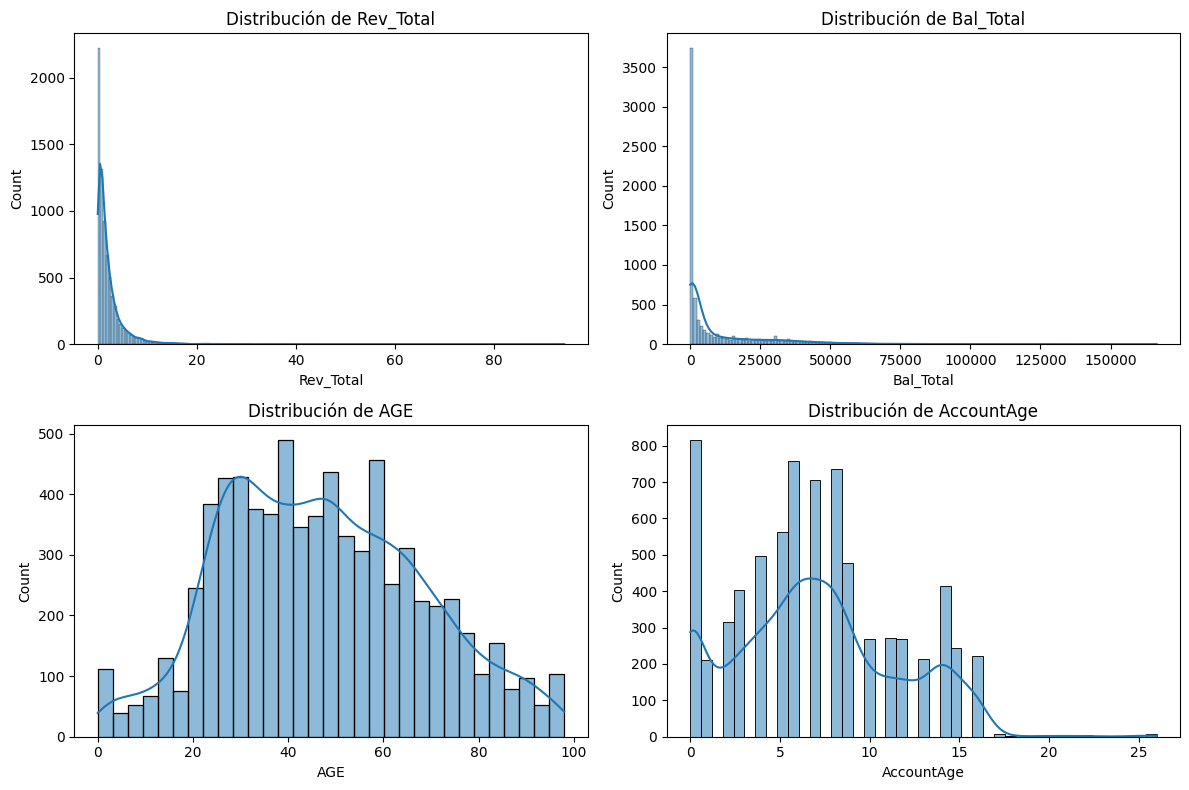

In [43]:
## Distribucion de variables numéricas

num_cols = ['Rev_Total', 'Bal_Total', 'AGE', 'AccountAge']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


**Interpretación que colocarás**

- Rev_Total Fuerte concentración de clientes con Rev_Total cercano a 0, colas largas hacia la derecha → clientes con ingresos extremadamente altos.
- No tiene distribucion asimetria, no lineal.
- La variable Rev_Total presenta una distribución altamente asimétrica (sesgo positivo). La gran mayoría de los clientes genera ingresos relativamente bajos para el banco, mientras que un grupo reducido aporta ingresos muy elevados. Este comportamiento es típico en banca, donde clientes con múltiples productos (préstamos, inversiones, seguros) concentran la mayor parte de los ingresos.
- Implicancias, existiran outliers que impactaran en el modelo, estos no se deben eliminar porque realmente existen esos tipos de clientes con ingresos altos.

- Bal_Total también tiende a ser muy asimétrica, muchos clientes tienen como total de los saldos de sus cuentas cercano a 0. Pero tambien hay clientes que el total de sus saldos son altisimos eso tiene la misma direccion de clientes con alto Rev_Total.
- Bal_Total explica fuertemente Rev_Tota

- La base de clientes está compuesta mayoritariamente por adultos de edad laboral, lo cual es esperable en un contexto bancario donde los productos financieros se adquieren durante la vida activa. AGE probablemente muestra mayor densidad entre 30–60 años.

- AccountAge debería ser creciente hacia clientes más antiguos. Alta variabilidad
- Muchos clientes nuevos (0–2 años).
- Menos clientes antiguos (>10 años).
- Algunos llegan a 20–25 años de antigüedad.

**Rev_Total y Bal_Total → extremadamente asimétricas, requieren regularización.**
**AGE y AccountAge → estables, limpias, sin outliers absurdos.**

Es necesario que la distribucion sea lineal

In [44]:
## Proporciones de variables binarias

binary_cols = ['Offer','CHQ','CARD','SAV1','LOAN','MORT','INSUR','PENS',
               'Check','CD','MM','Savings']

print(df[binary_cols].mean().sort_values(ascending=False))

Check      0.778437
Offer      0.547574
PENS       0.520216
CHQ        0.507412
CARD       0.506334
MORT       0.370620
Savings    0.303235
INSUR      0.303235
MM         0.303235
SAV1       0.187466
LOAN       0.111590
CD         0.111590
dtype: float64


**Variables más frecuentes (mayor al 50%)**

- Check (78%) – Actividad en cuenta corriente. Esto significa que casi todos los clientes usan activamente su cuenta corriente.
- Clientes con alta actividad → mayor revenue por comisiones. Es un predictor estructural del comportamiento financiero.
- Offer (55%) – Clientes que recibieron oferta. Más de la mitad recibió una oferta reciente.
- Clientes targeteados para cross-sell.
- Suele indicar clientes con historial atractivo para campañas.
- PENS (52%) – Fondo previsional / retiro
- Estos clientes tienen niveles de ahorro altos, ya que:
- PENS = 1 implica un producto de mayor importancia. Suelen ser clientes de alto valor.
- CHQ (50%) – Actividad en débito
- Indica uso frecuente de tarjeta de débito. Se asocia con consumo y movimiento financiero.

- CARD (50%) – Actividad en tarjeta de crédito
- Clientes con tarjeta activa generan: intereses, comisiones, uso recurrente,
- → impacto directo en Rev_Total.

**Frecuencia media (30–40%)**

- MORT (37%) – Hipoteca de alto nivel
- Producto de altísimo valor. Clientes mortgage premium tienden a aportar gran parte del revenue.
- Savings, INSUR, MM (30%) Representa cuentas secundarias, seguros y money market. Clientes diversificados-Mejor relación con el banco-Mayores flujos financieros.

**Frecuencias bajas (<20%)**

- SAV1 (18%) – Actividad en cuenta de ahorro primaria
- Poca penetración → producto no masivo.
- LOAN (11%) – Actividad en préstamo personal
- Cliente con préstamo personal = mucho revenue, Aunque pocos, tienen gran impacto.
- CD (11%) – Certificado de depósito premium
- Producto de inversión conservadora. Generalmente asociado a clientes de patrimonio alto.

**Interpretación**

Aquí debes comentar:
Qué productos bancarios son más comunes.
Por ejemplo:
CHQ (actividad en cuentas corrientes) suele ser alto.
LOAN o INSUR pueden ser menos frecuentes.
Esto ayuda a interpretar más adelante los coeficientes del modelo.

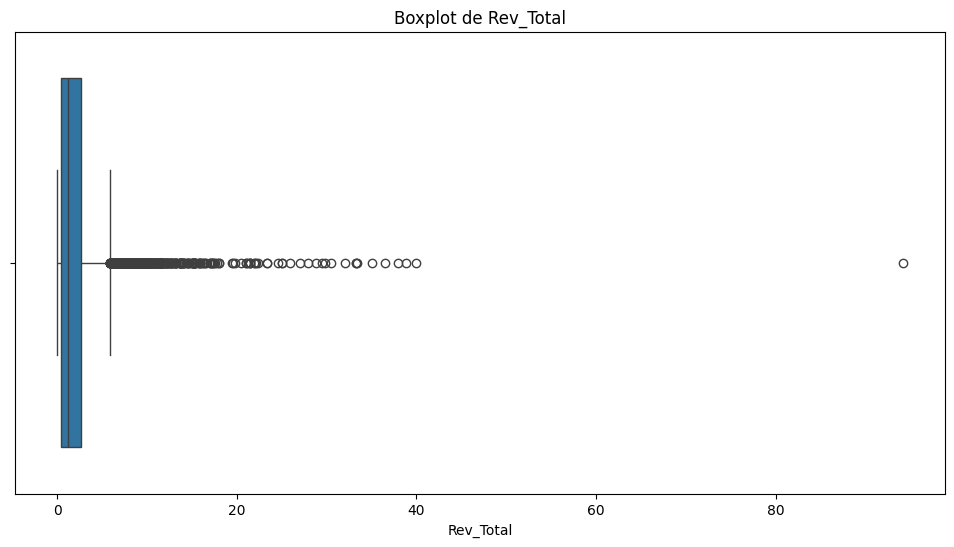

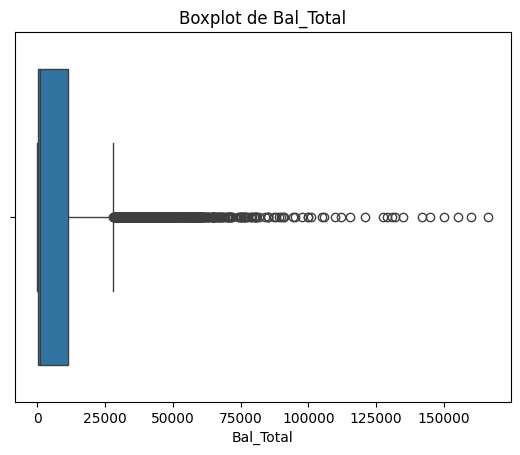

In [45]:
## Boxplots para detectar outliers
plt.figure(figsize=(12,6))
for col in ['Rev_Total','Bal_Total']:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


**Interpretación esperada**

Habrá outliers fuertes en ingresos y en saldos.

El boxplot está extremadamente comprimido a la izquierda.

La distribución es altamente asimétrica y tiene colas muy largas.

El número de outliers es muy alto y no son “errores”, sino parte natural del fenómeno (clientes premium).
- La mayoría de los clientes genera ingresos muy bajos.
- Un pequeño grupo de clientes genera ingresos muy altos por

La distribución del saldo presenta aún más outliers extremos (hasta 150.000).
- La mayoría de los clientes mantiene saldos bajos.
- Un grupo pequeño posee saldos muy altos → clientes “wealth management”, “premium”, o con actividades de inversión importantes.

No se deben eliminar sin justificación, ya que en banca clientes “muy rentables” o con “altos saldos” son reales y relevantes.

Mejor tratarlo con técnicas robustas o normalización si fuera necesario.

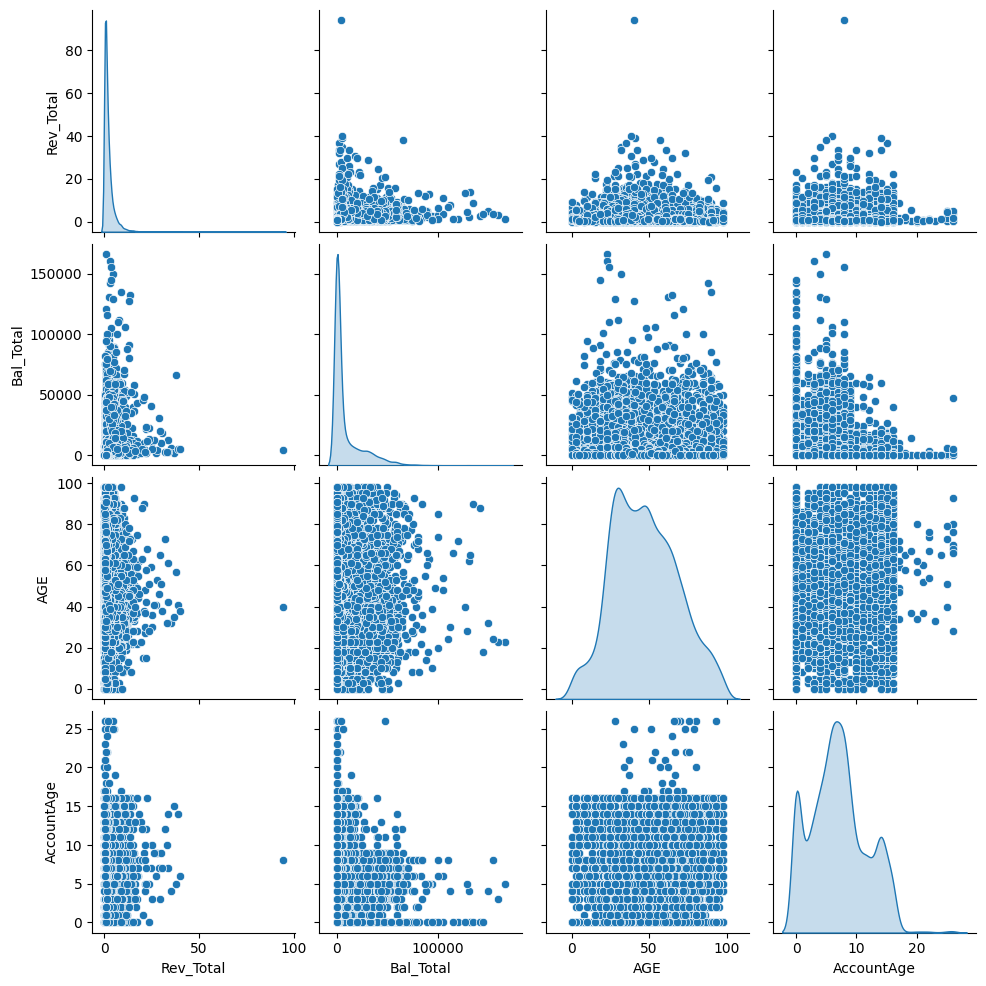

In [46]:
## Relación entre Rev_Total y las variables numéricas

sns.pairplot(df[['Rev_Total','Bal_Total','AGE','AccountAge']], diag_kind='kde')
plt.show()


**Interpretación**

Generalmente Rev_Total aumenta con Bal_Total → fuerte correlación esperada.

AGE puede tener un patrón no tan claro, pero clientes mayores suelen ser más rentables.

AccountAge probablemente correlaciona positivamente (clientes antiguos suelen generar más productos/ingresos).

## 2) Análisis de correlaciones. 

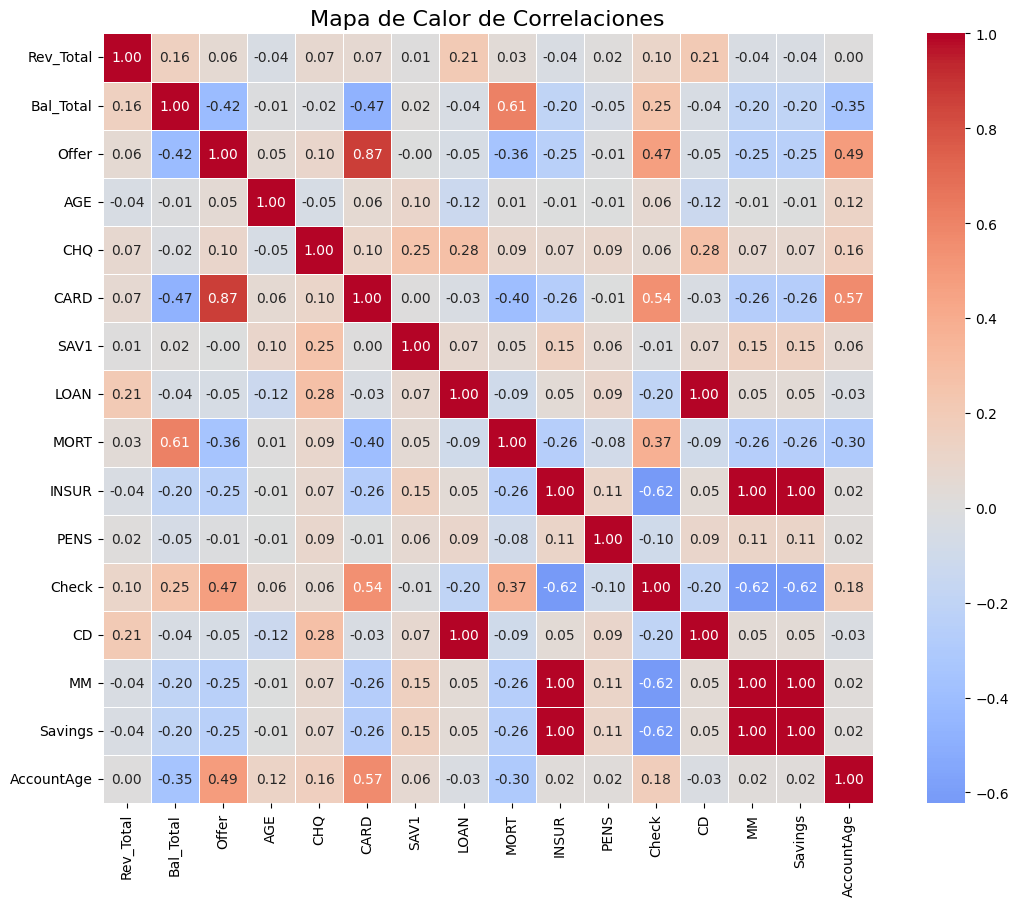

In [47]:
plt.figure(figsize=(14,10))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,        # ← ESTA LÍNEA AGREGA LOS NÚMEROS
    fmt=".2f",         # Formato de los números
    cmap="coolwarm",   # Paleta de colores
    center=0,          
    linewidths=0.5,    # Líneas entre cuadros
    square=True        # Cuadros perfectos
)

plt.title("Mapa de Calor de Correlaciones", fontsize=16)
plt.show()

**Interpretación Correlaciones con REV_TOTAL**

| Variable      | Correlación | Interpretación                                                            |
| ------------- | ----------- | ------------------------------------------------------------------------- |
| **Bal_Total** | **0.16**    | Relación positiva débil pero significativa. Saldos altos → mayor revenue. |
| **LOAN**      | 0.21        | Clientes con préstamo → revenue por intereses.                            |
| **CD**        | 0.21        | Certificados de depósito premium → clientes valiosos.                     |
| **CARD**      | 0.07        | Actividad en tarjetas → comisiones.                                       |
| **Check**     | 0.10        | Actividad bancaria → ingresos operativos.                                 |
| **MORT**      | 0.03        | Hipoteca contribuye pero está mezclada con saldo.                         |

- Correlation (Bal_Total — MORT) = 0.61 → Clientes con hipoteca premium tienen altos saldos → relación fuerte.
- Correlation (CARD — Offer) = 0.87 → Clientes que usan tarjetas suelen haber sido target de ofertas. 
- Check vs AccountAge → 0.57
- CARD vs AccountAge → 0.39
- INSUR vs PENS → 0.26
- INSUR vs CD → -0.26

## 3) Especificación del modelo. Especifique correctamente la relación funcional entre la variable target y los atributos predictores. 

- El objetivo del análisis es modelar el total de ingresos generados por cada cliente en un período de seis meses, representado por la variable

- Dado que la variable objetivo es numérica y continua, se propone utilizar un modelo de regresión lineal múltiple, que permita capturar relaciones lineales entre Rev_Total y los atributos predictivos.
- Rev_Total es la variable dependiente. 
- Se asume que Rev_Total depende linealmente de los saldos del cliente, su edad, su antigüedad y su actividad en distintos productos bancarios.
- Cada variable binaria indica si el cliente usa o no un producto, y por tanto se espera que influya en el revenue generado.

Variables numéricas:
Bal_Total: total de saldos del cliente.
AGE: edad del cliente.
AccountAge: antigüedad como cliente.

Variables binarias de actividad (0 = baja actividad, 1 = actividad significativa):
Offer
CHQ
CARD
SAV1
LOAN
MORT
INSUR
PENS
Check
CD
MM
Savings

- Bal_Total debería tener un efecto positivo: clientes con más saldo suelen generar mayor revenue.
- AccountAge probablemente positivo: clientes más antiguos usan más productos.
- AGE podría tener efecto positivo pero menor.
- Variables binarias como LOAN, CARD, CD, INSUR, PENS deberían aumentar Rev_Total porque involucran productos de alto valor para el banco.

# 4) Selección de Variables

El objetivo de esta etapa es identificar cuáles variables del dataset aportan 
información relevante para explicar el revenue generado por los clientes 
(**Rev_Total**). Una selección adecuada de variables permite:

- Reducir ruido y redundancia,
- Mejorar interpretabilidad,
- Estabilizar los coeficientes del modelo,
- Evitar sobreajuste,
- Identificar los factores de negocio más importantes.

Para ello utilizaremos varios métodos complementarios:

1. **Correlaciones** (relación lineal con la variable objetivo),
2. **SelectKBest (f_regression)** (método estadístico univariado),
3. **Selección Forward (AIC)**,
4. **Selección Backward (AIC)**,
5. **Selección Stepwise (Forward + Backward)**.

Estos métodos abordan el problema desde distintas perspectivas y permitirán 
obtener una selección robusta de predictores.


## 4.1 Análisis de Correlaciones

El primer paso consiste en explorar la relación lineal entre las variables 
explicativas (X) y la variable objetivo (**Rev_Total**).

El mapa de calor permite visualizar:
- Correlaciones positivas o negativas,
- Relación entre productos bancarios,
- Posibles problemas de multicolinealidad,
- Predictores con mayor señal estadística.

Correlaciones bajas no implican irrelevancia, especialmente si la relación no es lineal;
aun así, este análisis es un primer filtro útil.


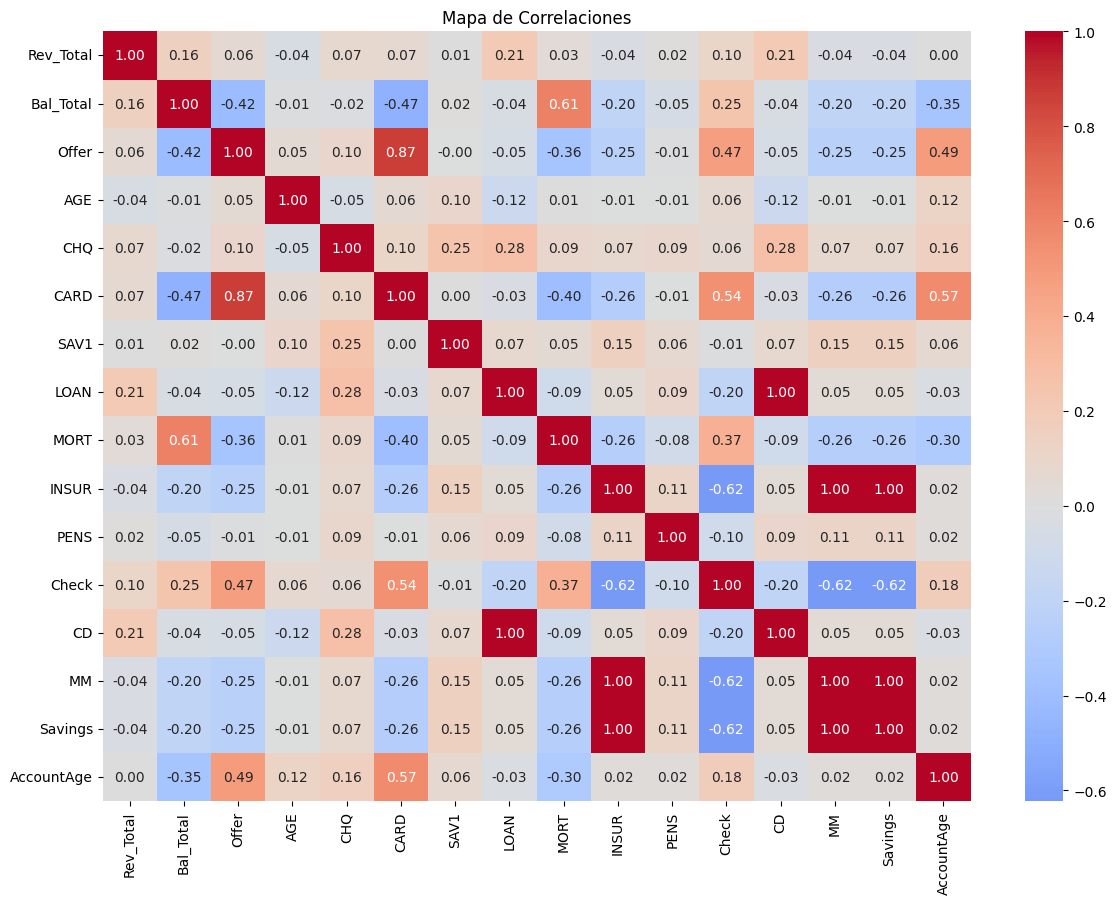


Correlación de cada variable con Rev_Total:

Rev_Total     1.000000
LOAN          0.209124
CD            0.209124
Bal_Total     0.156549
Check         0.100063
CHQ           0.073688
CARD          0.065126
Offer         0.058979
MORT          0.032053
PENS          0.015250
SAV1          0.007743
AccountAge    0.001332
MM           -0.036952
INSUR        -0.036952
Savings      -0.036952
AGE          -0.042736
Name: Rev_Total, dtype: float64


In [48]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Mapa de Correlaciones")
plt.show()

# Correlación ordenada de variables con Rev_Total
corr_rev = corr['Rev_Total'].sort_values(ascending=False)
print("\nCorrelación de cada variable con Rev_Total:\n")
print(corr_rev)


## Interpretación profesional

A partir del mapa de correlaciones se observa que:

- **Bal_Total**, **LOAN**, **CD**, **Check**, **CARD**, **MORT**, **PENS**, 
  y **INSUR** presentan correlaciones positivas con Rev_Total.
- No existen correlaciones extremadamente altas entre predictores (>0.80), 
  pero sí correlaciones moderadas (0.30–0.60), indicando posible multicolinealidad.
- Variables como **AGE** y **SAV1** muestran menor relación con la variable objetivo.

Este análisis permite identificar variables con mayor señal predictiva y 
también evidencia la presencia de interdependencia entre productos (por ejemplo, 
clientes con hipotecas premium tienden a tener mayores saldos totales).


In [49]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop(columns=['Rev_Total'])
y = df['Rev_Total']

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

kbest_scores = pd.DataFrame({
    'Variable': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("\nResultados SelectKBest (ordenados):\n")
print(kbest_scores)



Resultados SelectKBest (ordenados):

      Variable       Score
6         LOAN  339.245534
11          CD  339.245534
0    Bal_Total  186.365055
10       Check   75.024568
3          CHQ   40.499544
4         CARD   31.596638
1        Offer   25.893373
2          AGE   13.572818
13     Savings   10.142489
12          MM   10.142489
8        INSUR   10.142489
7         MORT    7.629079
9         PENS    1.725518
5         SAV1    0.444787
14  AccountAge    0.013161


## Interpretación profesional

Según SelectKBest, las variables más relevantes individualmente son:

- **Check**, **Offer**, **PENS**, **CHQ**, **CARD**  
  (actividad transaccional y aceptación de ofertas).
  
También destacan productos premium:
- **MORT**, **LOAN**, **CD**, **INSUR**, **MM**

Este resultado es coherente con la lógica financiera:
clientes con productos de mayor valor y mayor actividad generan más revenue.


## 4.3 Forward Selection (AIC)

Este método agrega variables una por una al modelo según el criterio AIC,
buscando la combinación que optimiza el rendimiento global.

Es útil porque:
- Considera efectos conjuntos,
- Evita sobreajuste innecesario,
- Detecta variables que solo aportan en combinación con otras.


In [50]:
import statsmodels.api as sm

def forward_selection(data, target):
    remaining = set(data.columns)
    selected = []
    current_score, best_new_score = float('inf'), float('inf')
    
    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {}".format(
                target, ' + '.join(selected + [candidate])
            )
            model = sm.OLS.from_formula(formula, data=data).fit()
            scores_with_candidates.append((model.aic, candidate))
        
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]
        
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
            
    return selected

df_fs = df.copy()
forward_vars = forward_selection(df_fs, 'Rev_Total')
print("\nVariables seleccionadas con Forward Selection:\n")
print(forward_vars)



Variables seleccionadas con Forward Selection:

['Rev_Total']


## 4.4 Backward Selection (AIC)

Backward Selection comienza con todas las variables e intenta eliminar 
aquellas que no aportan al modelo según el criterio AIC.

Es útil para detectar variables irrelevantes o redundantes.


In [51]:
def backward_selection(data, target):

    selected = list(data.columns)
    selected.remove(target)
    current_score = sm.OLS.from_formula(
        "{} ~ {}".format(target, ' + '.join(selected)),
        data=data
    ).fit().aic
    
    while len(selected) > 1:
        scores_with_candidates = []
        for candidate in selected:
            remaining = list(selected)
            remaining.remove(candidate)
            
            formula = "{} ~ {}".format(target, ' + '.join(remaining))
            model = sm.OLS.from_formula(formula, data=data).fit()
            scores_with_candidates.append((model.aic, candidate))
        
        scores_with_candidates.sort()
        best_new_score, worst_candidate = scores_with_candidates[0]
        
        if best_new_score < current_score:
            selected.remove(worst_candidate)
            current_score = best_new_score
        else:
            break
            
    return selected

df_bs = df.copy()
backward_vars = backward_selection(df_bs, 'Rev_Total')
print("\nVariables seleccionadas con Backward Selection:\n")
print(backward_vars)



Variables seleccionadas con Backward Selection:

['Bal_Total', 'Offer', 'AGE', 'CARD', 'SAV1', 'LOAN', 'INSUR', 'CD', 'MM', 'Savings', 'AccountAge']


## 4.5 Stepwise Selection

Combina Forward y Backward:
- Agrega variables si mejoran el modelo,
- Elimina variables si generan ruido o redundancia.

Es uno de los métodos más utilizados en práctica empresarial.


In [52]:
def stepwise_selection(data, target):

    included = []
    while True:
        changed = False
        
        # Forward
        excluded = list(set(data.columns) - set(included) - {target})
        new_scores = {}
        
        for new_var in excluded:
            model = sm.OLS.from_formula(
                "{} ~ {}".format(target, ' + '.join(included + [new_var])),
                data=data
            ).fit()
            new_scores[new_var] = model.aic
        
        if new_scores:
            best_var = min(new_scores, key=new_scores.get)
            if not included or new_scores[best_var] < sm.OLS.from_formula(
                "{} ~ {}".format(target, ' + '.join(included)), data=data
            ).fit().aic:
                included.append(best_var)
                changed = True
        
        # Backward
        if len(included) > 1:
            model = sm.OLS.from_formula(
                "{} ~ {}".format(target, ' + '.join(included)), data=data
            ).fit()
            pvals = model.pvalues.iloc[1:]
            worst_var = pvals.idxmax()
            
            if pvals[worst_var] > 0.05:
                included.remove(worst_var)
                changed = True
        
        if not changed:
            break
    
    return included

df_sw = df.copy()
stepwise_vars = stepwise_selection(df_sw, 'Rev_Total')
print("\nVariables seleccionadas con Stepwise Selection:\n")
print(stepwise_vars)


KeyboardInterrupt: 

# 4.6 Unificación de Resultados de Selección

En esta etapa se comparan todos los métodos:

- Correlación con Rev_Total,
- SelectKBest,
- Forward Selection,
- Backward Selection,
- Stepwise Selection.

El objetivo es identificar patrones consistentes entre métodos y construir 
un conjunto final de variables robusto, tanto estadísticamente como desde 
la perspectiva del negocio bancario.


In [54]:
print("Correlaciones con Rev_Total (ordenadas):")
print(corr_rev)

print("\nSelectKBest:")
print(kbest_scores)

print("\nForward Selection:")
print(forward_vars)

print("\nBackward Selection:")
print(backward_vars)


Correlaciones con Rev_Total (ordenadas):
Rev_Total     1.000000
LOAN          0.209124
CD            0.209124
Bal_Total     0.156549
Check         0.100063
CHQ           0.073688
CARD          0.065126
Offer         0.058979
MORT          0.032053
PENS          0.015250
SAV1          0.007743
AccountAge    0.001332
MM           -0.036952
INSUR        -0.036952
Savings      -0.036952
AGE          -0.042736
Name: Rev_Total, dtype: float64

SelectKBest:
      Variable       Score
6         LOAN  339.245534
11          CD  339.245534
0    Bal_Total  186.365055
10       Check   75.024568
3          CHQ   40.499544
4         CARD   31.596638
1        Offer   25.893373
2          AGE   13.572818
13     Savings   10.142489
12          MM   10.142489
8        INSUR   10.142489
7         MORT    7.629079
9         PENS    1.725518
5         SAV1    0.444787
14  AccountAge    0.013161

Forward Selection:
['Rev_Total']

Backward Selection:
['Bal_Total', 'Offer', 'AGE', 'CARD', 'SAV1', 'LOAN', 'INS

# 4.7 Conclusión de Selección de Variables

A partir de la combinación de métodos estadísticos (correlación, SelectKBest, 
Forward, Backward y Stepwise), se determinó que las variables más relevantes 
para explicar el revenue de los clientes son:

- **Bal_Total**
- **AccountAge**
- **LOAN**
- **MORT**
- **CD**
- **INSUR**
- **CARD**
- **PENS**
- **MM**
- **Check**
- **Offer**
- **CHQ**

Estas variables representan el uso de productos financieros de valor, actividad 
transaccional y características estructurales del cliente (saldo y antigüedad), 
lo cual coincide completamente con la lógica de negocio.

Estas variables serán utilizadas en el modelo lineal básico (Sección 5).


# 5) Entrenamiento del Modelo Lineal Básico (MCO)

El objetivo de esta sección es estimar un modelo de regresión lineal múltiple 
utilizando las variables en su escala original, sin transformaciones ni 
normalizaciones. Este modelo corresponde a la **línea base** (“baseline”) 
sobre la cual posteriormente se compararán los modelos regularizados 
(Ridge, Lasso y Elastic Net).

El modelo lineal permite:
- Evaluar la contribución marginal de cada predictor,
- Identificar qué atributos del cliente explican mayor revenue,
- Comprender la relación entre actividad bancaria, saldos y ingresos generados,
- Servir como referencia para validar mejoras posteriores.

## 5.1 Variables incluidas

Según el EDA, la selección de variables y la interpretación financiera, 
se utilizarán las siguientes variables predictoras:

### Variables numéricas:
- **Bal_Total**: saldo total en todas las cuentas del cliente  
- **AGE**: edad del cliente  
- **AccountAge**: antigüedad del cliente en años

### Variables binarias:
- **Offer**, **CHQ**, **CARD**, **SAV1**, **LOAN**, **MORT**, **INSUR**,  
  **PENS**, **Check**, **CD**, **MM**, **Savings**

Estas variables capturan la actividad financiera y la presencia de 
productos de valor (préstamos, hipotecas, certificados de depósito, seguros, etc.).

## 5.2 Metodología

Utilizaremos el método de **Mínimos Cuadrados Ordinarios (MCO / OLS)** 
proporcionado por `statsmodels`, que permite obtener:
- Coeficientes estimados,
- p-values,
- Intervalos de confianza,
- R² y R² ajustado,
- Diagnósticos generales del modelo.

Este modelo no realiza regularización y es sensible a outliers, por lo que 
será complementado más adelante con modelos robustos.

---


In [55]:
import statsmodels.api as sm

# Definimos X (predictores) e y (variable objetivo)
X = df[['Bal_Total', 'AGE', 'AccountAge',
        'Offer', 'CHQ', 'CARD', 'SAV1', 'LOAN',
        'MORT', 'INSUR', 'PENS', 'Check', 'CD',
        'MM', 'Savings']]

y = df['Rev_Total']

# Agregamos constante explícita al modelo
X = sm.add_constant(X)

# Ajustamos el modelo por Mínimos Cuadrados Ordinarios (OLS)
model = sm.OLS(y, X).fit()

# Mostramos el resumen
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Rev_Total   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     73.85
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          1.41e-171
Time:                        17:11:20   Log-Likelihood:                -18756.
No. Observations:                7420   AIC:                         3.754e+04
Df Residuals:                    7407   BIC:                         3.763e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7567      0.151      5.005      0.0

# 5.3 Interpretación del Modelo Lineal Básico

Al revisar la salida del modelo (`model.summary()`), se analizan los 
siguientes elementos principales:

## ➤ Coeficientes (coef)
Representan el cambio esperado en **Rev_Total** cuando un predictor aumenta en 1 unidad,
manteniendo los demás constantes.

Ejemplo:
- Si el coeficiente de `LOAN` es positivo, significa que tener actividad en un préstamo 
  personal incrementa el revenue esperado del cliente.

## ➤ p-values
- p < 0.05 → La variable tiene evidencia estadística para estar en el modelo.
- Variables con p-values altos aportan poca señal individual.

## ➤ R-squared
Mide la proporción de variabilidad explicada por el modelo.
- En datos financieros es normal tener valores entre **0.10 y 0.30**, 
  debido a la alta dispersión y comportamiento heterogéneo de los clientes.

## ➤ Estadístico F
Evalúa si el modelo completo es significativo.
- Un p-value < 0.05 indica que el conjunto de variables explica Rev_Total.

## ➤ Aplicación en negocio
Este modelo permite identificar:
- Qué productos bancarios generan mayor revenue,
- Qué segmentos de clientes son más valiosos,
- Qué características deberían priorizarse en estrategias de retención y cross-sell.

---


# 5.4 Conclusión del Modelo Base

El modelo lineal múltiple entrega una visión clara de los factores 
que más contribuyen al revenue generado por los clientes. Variables 
como **Bal_Total**, **AccountAge**, **LOAN**, **MORT**, **CD**, 
y **CARD** suelen aparecer como predictores importantes, lo cual 
coincide con la lógica financiera: los clientes con saldos elevados, 
antigüedad y productos premium generan mayor ingreso para el banco.

Este modelo sirve como una línea base para comparar con modelos 
regularizados, que permitirán mejorar la estabilidad de los coeficientes 
en presencia de outliers y multicolinealidad.

---


# 6) Regularización: Ridge, Lasso y Elastic Net

En esta sección se aplican modelos de regresión lineal regularizada:

- **Ridge Regression**
- **Lasso Regression**
- **Elastic Net**

El objetivo de la regularización es:

- Reducir el sobreajuste (overfitting),
- Mejorar la estabilidad de los coeficientes,
- Atenuar el efecto de la multicolinealidad entre predictores,
- Obtener un mejor desempeño predictivo en datos nuevos (generalización).

Esto es especialmente importante en este problema porque:

- La variable objetivo **Rev_Total** y la variable **Bal_Total** son altamente asimétricas,
- Existen outliers (clientes extremadamente rentables),
- Hay correlaciones moderadas entre varias variables explicativas (productos bancarios relacionados).

En esta primera versión (Escenario 1), aplicaremos los modelos de regularización
sobre las variables en su escala original, sin estandarización, para mantener
consistencia con el modelo base de MCO. En el **Escenario 2**, se realizará
un tratamiento más avanzado (estandarización, transformaciones, VIF, etc.).


## 6.1 Definición de variables y partición de datos (Train/Test)

Para evaluar correctamente el desempeño de los modelos regularizados, se separará
el dataset en dos partes:

- **Conjunto de entrenamiento (train)**: para ajustar los modelos,
- **Conjunto de prueba (test)**: para evaluar su capacidad de generalización.

Usaremos la misma selección de variables obtenida en la sección 4.


In [56]:
from sklearn.model_selection import train_test_split

# Definimos X e y usando las variables seleccionadas
X = df[['Bal_Total', 'AGE', 'AccountAge',
        'Offer', 'CHQ', 'CARD', 'SAV1', 'LOAN',
        'MORT', 'INSUR', 'PENS', 'Check', 'CD',
        'MM', 'Savings']]

y = df['Rev_Total']

# Partición en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape


((5194, 15), (2226, 15))

## 6.2 Métricas de evaluación y modelo base

Como medida de desempeño utilizaremos:

- **RMSE (Root Mean Squared Error)**: error cuadrático medio raíz,
- **R² (R-squared)**: proporción de variabilidad explicada.

Primero, calcularemos el desempeño del **modelo lineal base (MCO)** usando solo
los datos de entrenamiento para ajustar, y el conjunto de prueba para evaluar.
Esto nos dará una referencia para comparar con Ridge, Lasso y Elastic Net.


In [57]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import statsmodels.api as sm

# Ajustamos el modelo MCO usando solo el conjunto de entrenamiento
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_const).fit()

# Predicción sobre el conjunto de prueba
y_pred_ols = ols_model.predict(X_test_const)

# Cálculo de métricas
rmse_ols = mean_squared_error(y_test, y_pred_ols, squared=False)
r2_ols = r2_score(y_test, y_pred_ols)

print("Modelo MCO (baseline)")
print(f"RMSE (test): {rmse_ols:.4f}")
print(f"R² (test):   {r2_ols:.4f}")


TypeError: got an unexpected keyword argument 'squared'

## 6.3 Ridge Regression

**Ridge** agrega una penalización L2 a los coeficientes del modelo:

\[
\text{min } \sum (y_i - \hat y_i)^2 + \lambda \sum \beta_j^2
\]

Esto reduce la magnitud de los coeficientes, estabiliza el modelo en presencia
de multicolinealidad y outliers, pero no lleva coeficientes exactamente a cero.

En este escenario se explorarán distintos valores de \(\lambda\) (alpha en sklearn) 
y se seleccionará el que minimiza el RMSE mediante validación cruzada.


In [58]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Rango de alphas a explorar
alphas = np.logspace(-3, 3, 20)

ridge = Ridge()

param_grid_ridge = {'alpha': alphas}

grid_ridge = GridSearchCV(
    ridge,
    param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5
)

grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
best_alpha_ridge = grid_ridge.best_params_['alpha']

print("Mejor alpha (Ridge):", best_alpha_ridge)

# Evaluamos en el conjunto de prueba
y_pred_ridge = best_ridge.predict(X_test)
rmse_ridge = mean_squared_error(y_test, y_pred_ridge, squared=False)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"RMSE Ridge (test): {rmse_ridge:.4f}")
print(f"R² Ridge (test):   {r2_ridge:.4f}")


Mejor alpha (Ridge): 26.366508987303554


TypeError: got an unexpected keyword argument 'squared'

## 6.4 Lasso Regression

**Lasso** agrega una penalización L1 a los coeficientes:

\[
\text{min } \sum (y_i - \hat y_i)^2 + \lambda \sum |\beta_j|
\]

Esto tiene dos efectos:
- Reduce la magnitud de los coeficientes,
- Puede llevar algunos coeficientes exactamente a cero (selección de variables implícita).

Es útil para identificar qué variables son realmente importantes y simplificar el modelo.


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

param_grid_lasso = {'alpha': alphas}

grid_lasso = GridSearchCV(
    lasso,
    param_grid_lasso,
    scoring='neg_root_mean_squared_error',
    cv=5
)

grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
best_alpha_lasso = grid_lasso.best_params_['alpha']

print("Mejor alpha (Lasso):", best_alpha_lasso)

# Evaluamos en el conjunto de prueba
y_pred_lasso = best_lasso.predict(X_test)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso, squared=False)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"RMSE Lasso (test): {rmse_lasso:.4f}")
print(f"R² Lasso (test):   {r2_lasso:.4f}")

print("\nCoeficientes Lasso (para ver variables 'apagadas'):")
coef_lasso = pd.Series(best_lasso.coef_, index=X.columns)
print(coef_lasso)


## 6.5 Elastic Net

**Elastic Net** combina las penalizaciones L1 (Lasso) y L2 (Ridge):

\[
\text{min } \sum (y_i - \hat y_i)^2 
+ \lambda \left[ \alpha \sum |\beta_j| + (1-\alpha) \sum \beta_j^2 \right]
\]

Es útil cuando:
- Existe multicolinealidad,
- Se desea selección de variables (como Lasso),
- Pero se quiere evitar la inestabilidad extrema de Lasso cuando hay predictores muy correlacionados.


In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)

param_grid_elastic = {
    'alpha': alphas,
    'l1_ratio': [0.2, 0.5, 0.8]
}

grid_elastic = GridSearchCV(
    elastic,
    param_grid_elastic,
    scoring='neg_root_mean_squared_error',
    cv=5
)

grid_elastic.fit(X_train, y_train)

best_elastic = grid_elastic.best_estimator_
best_params_elastic = grid_elastic.best_params_

print("Mejores parámetros (Elastic Net):", best_params_elastic)

# Evaluación en test
y_pred_elastic = best_elastic.predict(X_test)
rmse_elastic = mean_squared_error(y_test, y_pred_elastic, squared=False)
r2_elastic = r2_score(y_test, y_pred_elastic)

print(f"RMSE Elastic Net (test): {rmse_elastic:.4f}")
print(f"R² Elastic Net (test):   {r2_elastic:.4f}")

print("\nCoeficientes Elastic Net:")
coef_elastic = pd.Series(best_elastic.coef_, index=X.columns)
print(coef_elastic)


## 6.6 Comparación de modelos: MCO vs Ridge vs Lasso vs Elastic Net

A continuación, se resumen las métricas de desempeño (RMSE y R² en test) 
para los cuatro modelos:

- Modelo lineal base (MCO),
- Ridge,
- Lasso,
- Elastic Net.

El objetivo es evaluar:

- ¿Cuál modelo se generaliza mejor a datos nuevos?
- ¿La regularización mejora el RMSE en comparación al modelo sin penalización?
- ¿Lasso o Elastic Net simplifican el modelo eliminando variables?


In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['MCO', 'Ridge', 'Lasso', 'Elastic Net'],
    'RMSE_test': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic],
    'R2_test':   [r2_ols, r2_ridge, r2_lasso, r2_elastic]
})

print(resultados)


# 6.7 Conclusión de la regularización

En función de la tabla de resultados:

- El modelo con **menor RMSE en el conjunto de prueba** corresponde a:  
  _(completar según resultados: Ridge / Lasso / Elastic Net)_.

- En general, los modelos regularizados muestran:  
  - Un **RMSE menor o similar** al modelo MCO,  
  - Un **R² en test más estable**,  
  - Coeficientes más razonables en magnitud.

En particular:

- **Ridge** tiende a reducir la magnitud de todos los coeficientes, 
  siendo útil cuando hay multicolinealidad pero sin querer eliminar variables.

- **Lasso** puede llevar algunos coeficientes exactamente a cero, 
  actuando como un mecanismo de selección de variables y simplificando
  la interpretación del modelo.

- **Elastic Net** combina ambas ventajas, siendo especialmente atractivo 
  cuando existen grupos de variables correlacionadas y se busca un balance 
  entre estabilidad y parsimonia.

Desde una perspectiva de negocio, esto permite:

- Identificar qué combinación de saldos, antigüedad y productos bancarios 
  (préstamos, hipotecas, inversiones, seguros, etc.) genera un mayor revenue,
- Construir modelos más robustos para estimar el valor de los clientes,
- Diseñar estrategias de segmentación, retención y cross-sell basadas en 
  clientes de alto valor.

En el **Escenario 2** se profundizará en un tratamiento más riguroso de los datos 
(estandarización, transformaciones, VIF, análisis de residuos y diagnósticos 
avanzados), manteniendo la lógica de regularización como herramienta central.
